In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision
importlib.reload(collision)
from collision import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec
counter = 0

In [3]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 51 / e_mass      # now in a.u.
c6 = 7700         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (uK)", E_beta * t0 * 1e6)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 92967.31280765879
C6 7700
beta (a0) 194.51932314094483
E_beta (uK) 44.88404310178714
tau_beta (s) 1.0692536510917182e-06


In [4]:
num_samples = 5000

# properties of resonant spectrum
rrkm = 0.39e-3 / 1e5     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos
print(mean_spacing)

# thermal properties
temp = 0.17         # in terms of E6
num_resonances = 400        # should be odd

274.16760284403034


found
69.2830904376463
129.3164660243099


C:\Users\kevin\AppData\Local\Temp\ipykernel_18256\3541105803.py:27: RuntimeWarning: invalid value encountered in log
  res = sc.stats.linregress(np.log(energy_grid)[:cutoff], np.log(time_delays)[:cutoff])


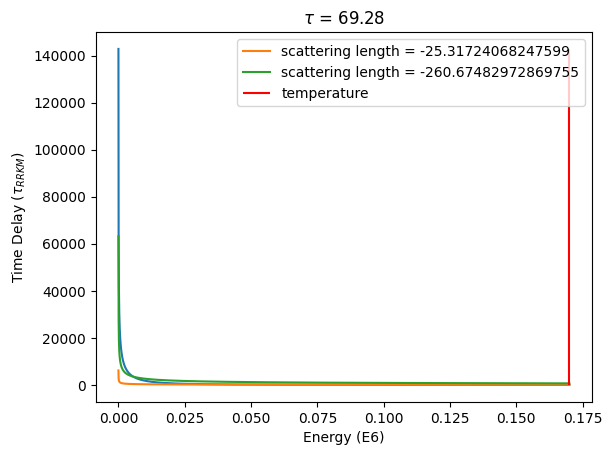

LinregressResult(slope=np.float64(-0.5889087586119057), intercept=np.float64(5.56327376748161), rvalue=np.float64(-0.9975993612759505), pvalue=np.float64(1.8499788071163664e-115), stderr=np.float64(0.004129489936661643), intercept_stderr=np.float64(0.030569051709731072))
LinregressResult(slope=np.float64(-0.5000000000000001), intercept=np.float64(3.231485613552156), rvalue=-1.0, pvalue=np.float64(0.0), stderr=np.float64(0.0), intercept_stderr=np.float64(0.0))


C:\Users\kevin\AppData\Local\Temp\ipykernel_18256\3541105803.py:43: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(energy_grid), np.log(time_delays))
C:\Users\kevin\AppData\Local\Temp\ipykernel_18256\3541105803.py:44: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(energy_grid)[:cutoff], np.log(time_delays)[:cutoff])
C:\Users\kevin\AppData\Local\Temp\ipykernel_18256\3541105803.py:46: RuntimeWarning: invalid value encountered in log
  res = sc.stats.linregress(np.log(energy_grid)[:cutoff], np.log(time_delays)[:cutoff])


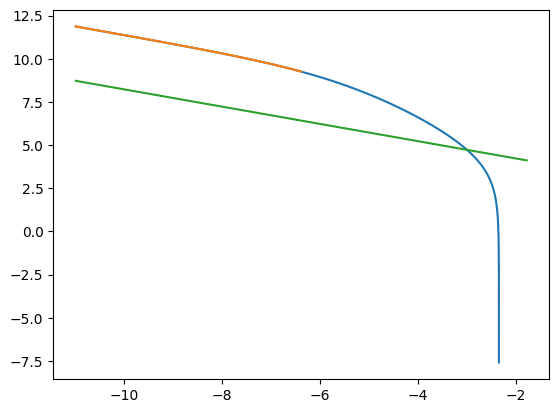

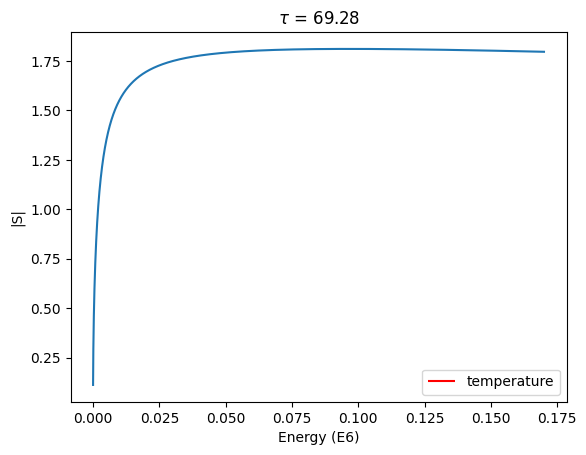

In [66]:
counter += 1
mean_x = 10
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

while True:
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    min_positive = np.min(energy_GOE_mat[energy_GOE_mat > 0])
    max_negative = np.max(energy_GOE_mat[energy_GOE_mat < 0])

    f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
    time_delay = sc.integrate.quad(f, 0, 10 * temp)[0] * (mean_spacing / 2 / np.pi)

    if time_delay > 50:
        print("found")
        break

a = -np.sqrt(np.pi * temp) / 2 * time_delay
tau = lambda E : -a / np.sqrt(E)
g = lambda energy : relative_MB_weights(temp, energy) * tau(energy)
print(sc.integrate.quad(g, 0, 10 * temp)[0])

energy_grid = np.linspace(0, 1 * temp, 10000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
time_delays = (mean_spacing / 2 / np.pi) * time_delays

cutoff = 100
res = sc.stats.linregress(np.log(energy_grid)[:cutoff], np.log(time_delays)[:cutoff])
tau_fit = lambda E : np.exp(res.intercept) / np.sqrt(E)
h = lambda energy : relative_MB_weights(temp, energy) * tau_fit(energy)
print(sc.integrate.quad(h, 0, 0.2 * temp)[0])

plt.plot(energy_grid, time_delays)
plt.plot(energy_grid, tau(energy_grid), label=f"scattering length = {a}")
plt.plot(energy_grid, tau_fit(energy_grid), label=f"scattering length = {-np.exp(res.intercept)}")
plt.vlines(temp, min(time_delays), max(time_delays), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_{RRKM}$)")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
# plt.savefig(f"RbKRb/spectrum/positive_{counter}.pdf")
plt.show()

plt.plot(np.log(energy_grid), np.log(time_delays))
plt.plot(np.log(energy_grid)[:cutoff], np.log(time_delays)[:cutoff])
plt.plot(np.log(energy_grid), np.log(tau(energy_grid)))
res = sc.stats.linregress(np.log(energy_grid)[:cutoff], np.log(time_delays)[:cutoff])
print(res)
print(sc.stats.linregress(np.log(energy_grid), np.log(tau(energy_grid))))
plt.show()

S_mat = S_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
plt.plot(energy_grid, np.abs(1-S_mat))
plt.vlines(temp, min(np.abs(S_mat)), max(np.abs(S_mat)), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel("|S|")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.savefig(f"RbKRb/spectrum/S_positive_{counter}.pdf")
plt.show()


In [148]:
import pickle

xs = [0]
data = []

for mean_x in xs:
    mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

    time_delays = []
    Q_mats = []
    for i in range(1000):
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

        f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
        time_delay = sc.integrate.quad(f, 0, 10 * temp)[0] * (mean_spacing / 2 / np.pi)
        time_delays.append(time_delay)

        energy_grid = np.linspace(0, 1 * temp, 10000)[1:]
        Q_mat = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
        Q_mat = (mean_spacing / 2 / np.pi) * Q_mat

        cutoff = 100
        Q_mats.append(Q_mat[:cutoff])

    normalized = np.array(time_delays) * (mean_spacing / 2 / np.pi)
    mean_delay = np.mean(normalized)

    data_point = {"delays" : time_delays, "Q" : Q_mats, "mean_x" : mean_x}
    data.append(data_point)

with open("RbKRb/spectrum/scattering_lengths_small.pkl", "wb") as f:
    pickle.dump(data, f)




In [39]:
np.exp(3.4415057099006736)

np.float64(31.233952050693805)

C:\Users\kevin\AppData\Local\Temp\ipykernel_18256\2373791317.py:2: RuntimeWarning: divide by zero encountered in divide
  y = 1 / np.sqrt(x)
C:\Users\kevin\AppData\Local\Temp\ipykernel_18256\2373791317.py:3: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(x), np.log(y))


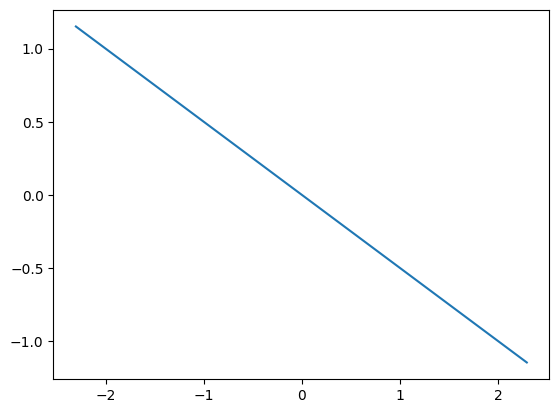

In [33]:
x = np.arange(0, 10, 0.1)
y = 1 / np.sqrt(x)
plt.plot(np.log(x), np.log(y))

found


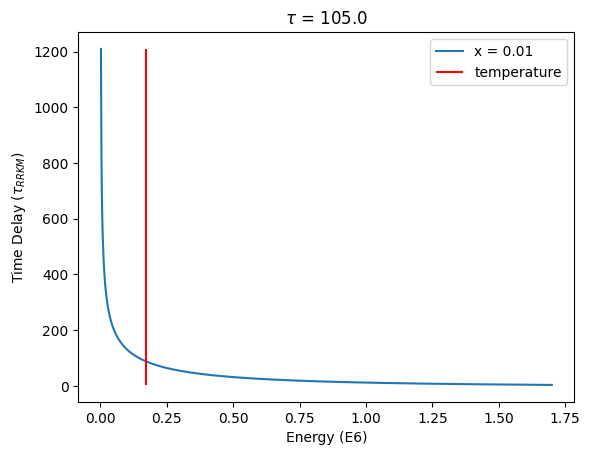

found


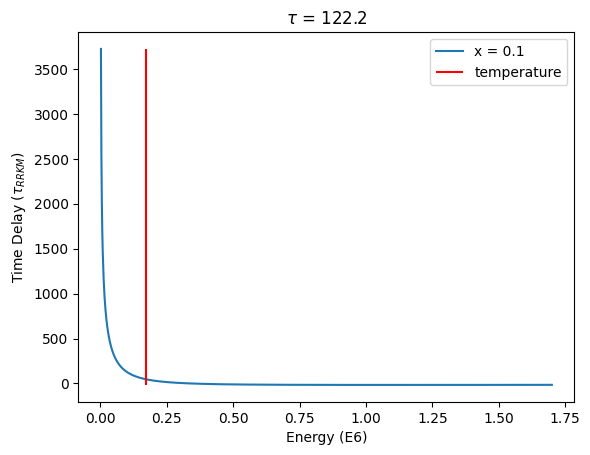

found


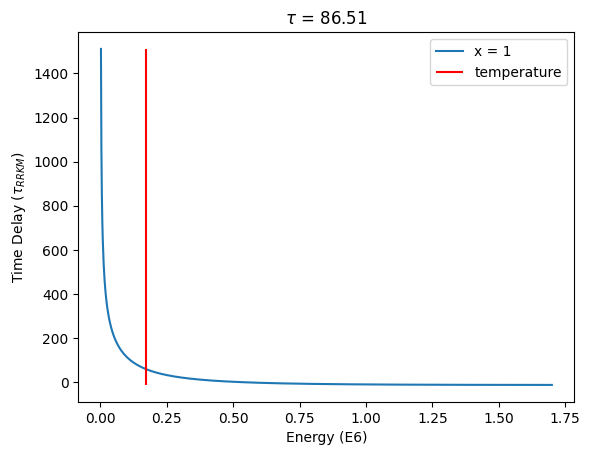

found


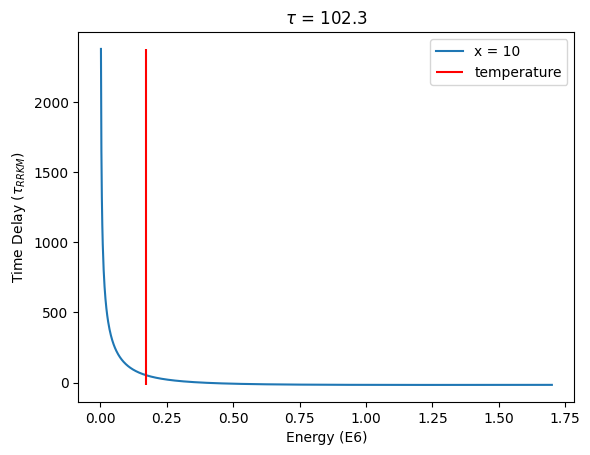

found


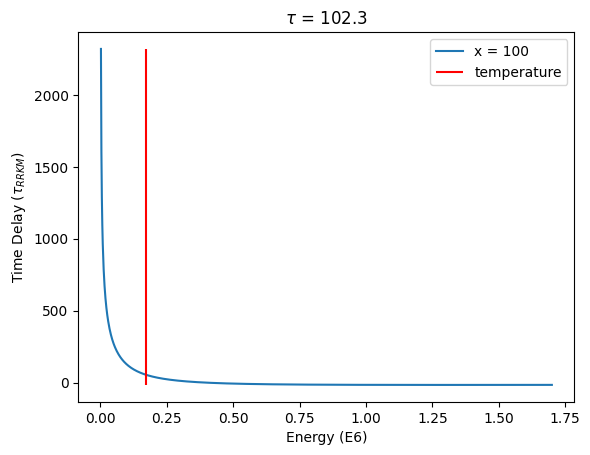

In [64]:
for mean_x in [0.01, 0.1, 1, 10, 100]:
    mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

    while True:
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
        min_positive = np.min(energy_GOE_mat[energy_GOE_mat > 0])
        max_negative = np.max(energy_GOE_mat[energy_GOE_mat < 0])

        f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
        time_delay = sc.integrate.quad(f, 0, 10 * temp)[0] * (mean_spacing / 2 / np.pi)

        if time_delay > 50:
            print("found")
            break

    energy_grid = np.linspace(0, 10 * temp, 1000)[1:]
    time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
    time_delays = (mean_spacing / 2 / np.pi) * time_delays
    plt.plot(energy_grid, time_delays, label=f"x = {mean_x}")

    plt.vlines(temp, min(time_delays), max(time_delays), colors="red", label="temperature")
    plt.legend()
    plt.xlabel("Energy (E6)")
    plt.ylabel(r"Time Delay ($\tau_{RRKM}$)")
    plt.title(r"$\tau$ = " + str(time_delay)[:5])
    # plt.ylim([0, 50])
    # plt.savefig(f"RbCs/spectrum/positive_{counter}.pdf")
    plt.show()


In [ ]:
counter += 1
mean_x = 10
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

while True:
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    min_positive = np.min(energy_GOE_mat[energy_GOE_mat > 0])
    max_negative = np.max(energy_GOE_mat[energy_GOE_mat < 0])

    f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
    time_delay = sc.integrate.quad(f, 0, 10 * temp)[0] * (mean_spacing / 2 / np.pi)

    if time_delay < 0:
        print("found")
        break

energy_grid = np.linspace(0, 10 * temp, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid, time_delays)
plt.vlines(temp, min(time_delays), max(time_delays), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_{RRKM}$)")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.savefig(f"RbKRb/spectrum/negative_{counter}.pdf")
plt.show()

S_mat = S_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
plt.plot(energy_grid, np.abs(S_mat))
plt.vlines(temp, min(np.abs(S_mat)), max(np.abs(S_mat)), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel("|S|")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.savefig(f"RbKRb/spectrum/S_negative_{counter}.pdf")
plt.show()


In [21]:
xs = np.round(np.pow(10, np.arange(-2, 2, 0.1)), 3)
xs

array([1.0000e-02, 1.3000e-02, 1.6000e-02, 2.0000e-02, 2.5000e-02,
       3.2000e-02, 4.0000e-02, 5.0000e-02, 6.3000e-02, 7.9000e-02,
       1.0000e-01, 1.2600e-01, 1.5800e-01, 2.0000e-01, 2.5100e-01,
       3.1600e-01, 3.9800e-01, 5.0100e-01, 6.3100e-01, 7.9400e-01,
       1.0000e+00, 1.2590e+00, 1.5850e+00, 1.9950e+00, 2.5120e+00,
       3.1620e+00, 3.9810e+00, 5.0120e+00, 6.3100e+00, 7.9430e+00,
       1.0000e+01, 1.2589e+01, 1.5849e+01, 1.9953e+01, 2.5119e+01,
       3.1623e+01, 3.9811e+01, 5.0119e+01, 6.3096e+01, 7.9433e+01])

In [165]:
with open("RbKRb/spectrum/scattering_lengths_small.pkl", "rb") as f:
    scattering_lengths = pickle.load(f)

xs = np.round(np.pow(10, np.arange(-2, 2, 0.2)), 3)

print(scattering_lengths[0]["Q"][5][0])

-5058.337564086597


In [162]:
energy_grid = np.linspace(0, 1 * temp, 10000)[1:]
abar = (np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2

for i in range(len(xs)):
    x = xs[i]
    delays = scattering_lengths[i]["delays"]
    Q_mats = scattering_lengths[i]["Q"]
    # print(Q_mats[0])

    lengths = []
    good_delays = []

    for i in range(len(Q_mats)):
        Q_mat = Q_mats[i] / (mean_spacing / 2 / np.pi)
        for cutoff in range(len(Q_mat) - 1, 1, -1):
            res = sc.stats.linregress(np.log(energy_grid)[:cutoff], np.log(np.abs(Q_mat))[:cutoff])
            if np.abs(res.rvalue) > 0.99:
                good_delays.append(delays[i])
                if Q_mat[0] > 0:
                    lengths.append(np.exp(res.intercept))
                else:
                    lengths.append(-np.exp(res.intercept))
                break


    plt.scatter(lengths, good_delays)
    plt.xlabel("Scattering Length")
    plt.ylabel("Time Delay")
    plt.title(f'x={x}')
    plt.savefig(f"RbKRb/scattering_length/x_{x}.pdf")
    plt.clf()
    # break
    


<Figure size 640x480 with 0 Axes>

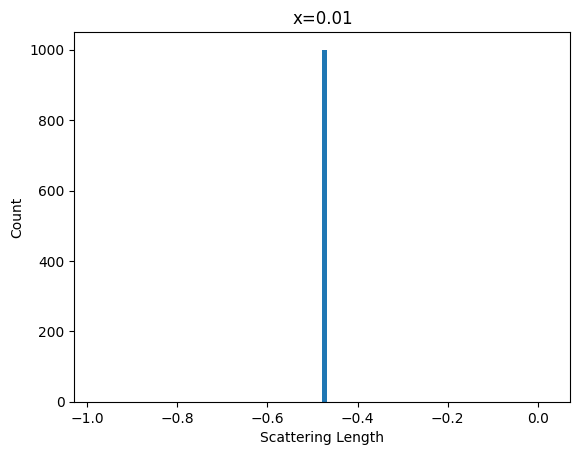

IndexError: list index out of range

<Figure size 640x480 with 0 Axes>

In [166]:
energy_grid = np.linspace(0, 1 * temp, 10000)[1:]

for i in range(len(xs)):
    x = xs[i]
    delays = scattering_lengths[i]["delays"]
    Q_mats = scattering_lengths[i]["Q"]
    # print(Q_mats[0])

    lengths = []
    good_delays = []

    for i in range(len(Q_mats)):
        Q_mat = Q_mats[i] / (mean_spacing / 2 / np.pi)
        for cutoff in range(len(Q_mat) - 1, 1, -1):
            res = sc.stats.linregress(np.log(energy_grid)[:cutoff], np.log(np.abs(Q_mat))[:cutoff])
            if np.abs(res.rvalue) > 0.99:
                good_delays.append(delays[i])
                if Q_mat[0] > 0:
                    lengths.append(np.exp(res.intercept))
                else:
                    lengths.append(-np.exp(res.intercept))
                break


    plt.hist(lengths, bins=100)
    plt.xlabel("Scattering Length")
    plt.ylabel("Count")
    plt.title(f'x={x}')
    plt.show()
    plt.savefig(f"RbKRb/scattering_length/hist_x_{x}.pdf")
    plt.clf()
    # break
    


In [145]:
energy_grid = np.linspace(0, 10 * temp, 1000)[1:]
time_delays = wigner_smith_matrix_single(energy_grid, 0, 0)

0.47798879748612494


274.16760284403034 0.0
LinregressResult(slope=np.float64(-0.5000000000000003), intercept=np.float64(-0.7381679829868109), rvalue=-1.0, pvalue=np.float64(0.0), stderr=np.float64(0.0), intercept_stderr=np.float64(0.0))
0.47798879748612433


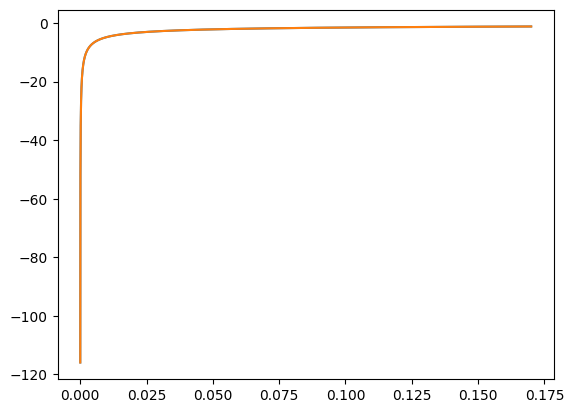

In [159]:
def test(collision_energy, H_goe, W_squared):
    # values for calculation
    k = np.sqrt(collision_energy)
    A_mqdt = abar * k
    A_prime = abar / 2 / k
    G_mqdt = (1 / 3 - abar ** 2) * np.square(k)
    G_prime = (1 / 3 - abar ** 2)
    eta_mqdt = -abar * k
    eta_prime = -abar / 2 / k 

    collision_energy = np.reshape(collision_energy, (len(collision_energy), 1))
    energy_diff = collision_energy - H_goe
    ratio = W_squared / energy_diff

    Y_mat = -np.pi * np.sum(ratio, axis=1)
    Y_prime = np.pi * np.sum(ratio / energy_diff, axis=1)
    print(Y_mat, Y_prime)

    K_mat = A_mqdt * Y_mat / (1 + G_mqdt * Y_mat)
    K_prime = (A_prime * Y_mat + A_mqdt * Y_prime) / (1 + G_mqdt * Y_mat) - A_mqdt * Y_mat * (G_prime * Y_mat + G_mqdt * Y_prime) / (1 + G_mqdt * Y_mat) ** 2
    print(K_mat, K_prime)

    Q_mat = 2 * (eta_prime + K_prime / (1 + K_mat ** 2))
    return Q_mat

def test(collision_energy, H_goe, W_squared):
    # values for calculation
    k = np.sqrt(collision_energy)
    A_mqdt = abar * k
    A_prime = abar / 2 / k
    G_mqdt = (1 / 3 - abar ** 2) * np.square(k)
    G_prime = (1 / 3 - abar ** 2)
    eta_mqdt = -abar * k
    eta_prime = -abar / 2 / k 

    Q_mat = 2 * (eta_prime)
    return Q_mat

print(mean_spacing, mean_coupling_strength)
energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

delays = test(energy_grid, energy_GOE_mat, np.square(W_mat)) 
f = lambda E : -abar / np.sqrt(E)
plt.plot(energy_grid, delays)
plt.plot(energy_grid, f(energy_grid))

cutoff = 50
res = sc.stats.linregress(np.log(energy_grid)[:cutoff], np.log(np.abs(delays))[:cutoff])
print(res)
print(np.exp(res.intercept))
